In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
%matplotlib inline

In [15]:
# import the dataset
from sklearn.datasets import make_blobs


In [16]:
x,y=make_blobs(n_samples=1000,centers=3,n_features=2)
# it is going to make a dataset andthen divide it in 2 columns x and y
# hamara model x pr kam krega y pr bs check krega ki kya prdiction thik hai ki nahi

#centres=3 means ki 3 clusters bnenge
#n_feaures=2 mtlb do features honge
# aur 1000 rows hongi

In [17]:
x

array([[ -9.89505872,   8.79868776],
       [ -9.5448904 ,   7.96643922],
       [ -9.51177177,  10.07584961],
       ...,
       [ -7.03264496,   7.49018416],
       [ -1.36996808,   5.11470175],
       [-10.0310145 ,   8.66273242]])

In [18]:
y

array([2, 2, 2, 0, 1, 2, 2, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 1, 2, 0,
       1, 1, 2, 0, 1, 1, 1, 2, 2, 1, 2, 2, 1, 2, 2, 2, 0, 1, 1, 2, 1, 1,
       1, 0, 1, 1, 1, 2, 0, 2, 2, 2, 1, 1, 1, 0, 1, 2, 1, 1, 0, 1, 2, 2,
       0, 0, 2, 2, 0, 2, 0, 1, 2, 2, 2, 2, 2, 0, 2, 1, 2, 0, 0, 0, 2, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 2, 2, 1, 0, 1, 0, 0, 0,
       0, 2, 0, 0, 1, 2, 0, 2, 0, 2, 1, 1, 2, 2, 1, 0, 2, 1, 2, 0, 1, 1,
       0, 0, 0, 1, 1, 2, 2, 1, 2, 0, 1, 2, 2, 1, 1, 1, 0, 0, 1, 2, 0, 1,
       1, 2, 1, 2, 2, 1, 2, 1, 1, 0, 1, 2, 1, 2, 1, 0, 2, 2, 1, 1, 2, 0,
       0, 0, 0, 1, 2, 1, 2, 2, 2, 1, 2, 1, 0, 1, 2, 1, 0, 2, 0, 1, 0, 0,
       1, 0, 0, 1, 2, 0, 2, 0, 1, 0, 1, 0, 0, 0, 0, 0, 2, 2, 0, 1, 2, 2,
       2, 1, 0, 1, 0, 0, 2, 1, 1, 1, 0, 2, 1, 2, 2, 1, 1, 1, 2, 2, 1, 0,
       0, 2, 0, 0, 2, 2, 1, 1, 1, 1, 2, 1, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 2, 2, 2, 2, 2, 1, 0, 1, 0, 2, 1, 0, 0, 0, 0, 2,
       1, 1, 0, 2, 2, 2, 1, 2, 0, 1, 1, 2, 1, 2, 1,

# BUT IN REAL DATASET WE WILL NEVER KNOW HOW MANY CLUSTERS ARE THERE
- HENCE WE ARE GOING TO FIND NO OF FEATURES BY USING K MEANS AND VERIFY THEM FROM Y 

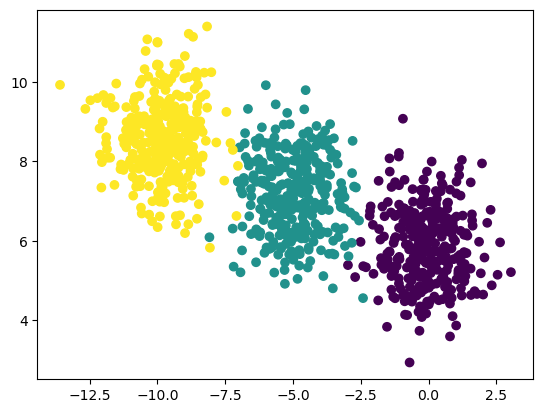

In [41]:
plt.scatter(x[:,0],x[:,1],c=y)
plt.show()

# NOW FINDING NO OF CLUSTERS NEEDED USING ELBOW TECHNIQUE

In [25]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.3)

In [28]:
x_scaled=sc.fit_transform(x_train)
test_scaled=sc.transform(x_test) # prevent data leakage


In [ ]:
from sklearn.cluster import KMeans


In [31]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

In [32]:
wcss

[1399.999999999999,
 509.3890662608094,
 310.8295810277988,
 252.5043104683475,
 191.70953744093015,
 137.38346242126642,
 123.14306433889554,
 114.72419256835836,
 97.30854665257681,
 87.95711775242927]

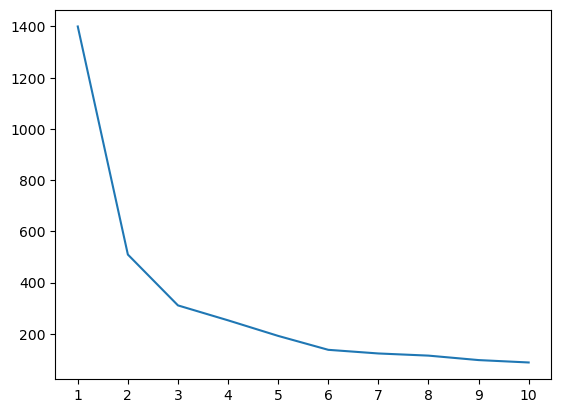

In [37]:

plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))# isse har value k liye apki corresponding value plot hojayegi
plt.show()

In [38]:
# hence dekho 3 tk giri iuske bad it got stabled !!!

kmeans=KMeans(n_clusters=3,init="k-means++")
kmeans.fit_predict(x_train)

array([0, 1, 0, 1, 1, 2, 0, 1, 2, 0, 0, 1, 2, 1, 1, 2, 0, 2, 2, 2, 2, 2,
       0, 2, 0, 1, 2, 2, 2, 2, 0, 0, 0, 1, 1, 1, 0, 2, 2, 1, 1, 1, 0, 2,
       1, 0, 2, 2, 0, 2, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 2, 0, 0,
       0, 1, 1, 2, 2, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 2,
       2, 2, 0, 1, 0, 2, 2, 0, 1, 2, 1, 0, 1, 0, 1, 0, 0, 2, 1, 2, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 2, 1, 0, 2, 1, 0, 2, 0, 0, 2, 0, 0, 1, 1, 2,
       1, 0, 2, 2, 1, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 1, 2, 0, 1, 2, 2,
       0, 1, 0, 2, 0, 2, 1, 2, 2, 0, 0, 0, 0, 0, 2, 1, 2, 0, 2, 2, 2, 1,
       0, 1, 2, 0, 1, 0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 1, 0, 1, 2, 1, 0,
       2, 0, 2, 2, 0, 2, 1, 0, 0, 0, 1, 1, 2, 1, 1, 2, 2, 1, 2, 0, 1, 0,
       0, 2, 1, 0, 2, 1, 1, 2, 2, 0, 2, 1, 0, 2, 0, 2, 0, 1, 0, 1, 2, 1,
       0, 2, 1, 1, 0, 0, 2, 1, 2, 1, 1, 2, 2, 1, 1, 2, 0, 2, 0, 1, 2, 2,
       2, 2, 0, 0, 2, 0, 2, 0, 1, 2, 2, 1, 0, 1, 1, 2, 0, 0, 0, 1, 0, 1,
       2, 1, 2, 2, 2, 2, 2, 0, 2, 0, 0, 2, 0, 1, 0,

In [39]:
y_pred=kmeans.predict(test_scaled)

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_pred,y_test))

[[  0   0   0]
 [  0   0   0]
 [112  95  93]]


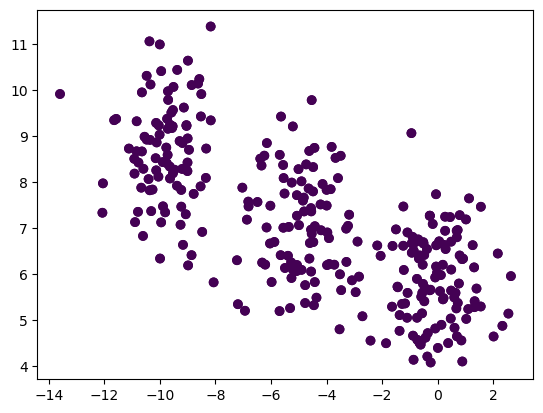

In [44]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_pred)
plt.show()